<a href="https://colab.research.google.com/github/kanokwantho/SC663402_Pandas_Review.ipynb/blob/main/Part1_243_5_%E0%B8%81%E0%B8%99%E0%B8%81%E0%B8%A7%E0%B8%A3%E0%B8%A3%E0%B8%93_%E0%B8%97%E0%B8%AD%E0%B8%87%E0%B9%80%E0%B8%97%E0%B8%9E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##นางสาวกนกวรรณ ทองเทพ 673020243-5

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [ ]:
# ============================================================
# PART 1: SOCIAL LISTENING WARM-UP
# Dataset: Two Million Bluesky Posts
# ============================================================

import requests
import json
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from collections import Counter


# ============================================================
# 1. ดาวน์โหลดข้อมูลจาก Hugging Face
# ============================================================

url = "https://huggingface.co/datasets/alpindale/two-million-bluesky-posts/resolve/main/posts_20241127_075630.jsonl"

file_path = "/content/bluesky_posts.jsonl"

response = requests.get(url)
response.raise_for_status()

with open(file_path, "wb") as f:
    f.write(response.content)

print("ดาวน์โหลดไฟล์เรียบร้อยแล้ว")
print("ชื่อไฟล์:", os.path.basename(file_path))
print("ขนาดไฟล์:", round(len(response.content) / (1024**2), 2), "MB")


# ============================================================
# 2. อ่าน JSONL ทีละบรรทัด
# ============================================================

def iter_jsonl(path):
    with open(path, encoding="utf-8") as f:
        for line in f:
            yield json.loads(line)


# ============================================================
# 3. ตรวจสอบฟิลด์ของข้อมูล
# ============================================================

for post in iter_jsonl(file_path):
    print("\nฟิลด์ที่มีในข้อมูล:")
    print(list(post.keys()))
    break


# ============================================================
# 4. สร้าง DataFrame
# ============================================================

data = []

for post in iter_jsonl(file_path):

    data.append({
        "text": post.get("text"),
        "created_at": post.get("created_at"),
        "author": post.get("author"),
        "uri": post.get("uri"),
        "has_images": post.get("has_images"),
        "reply_to": post.get("reply_to")
    })

df = pd.DataFrame(data)


# ============================================================
# 5. ตรวจสอบข้อมูลเบื้องต้น
# ============================================================

print("\n==============================")
print("ข้อมูลเบื้องต้น")
print("==============================")

print("จำนวนโพสต์:", f"{len(df):,}")
print("จำนวนคอลัมน์:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nตัวอย่างข้อมูล:")
display(df.head())


# ============================================================
# 6. ตรวจสอบ Missing Values
# ============================================================

print("\n==============================")
print("Missing Values")
print("==============================")

display(df.isna().sum())


# ============================================================
# 7. แปลง created_at เป็น datetime
# ============================================================

df["created_at"] = pd.to_datetime(
    df["created_at"],
    utc=True,
    errors="coerce"
)

print("\n==============================")
print("ตรวจสอบวันที่และเวลา")
print("==============================")

print("ข้อมูลเริ่มต้น:", df["created_at"].min())
print("ข้อมูลสิ้นสุด:", df["created_at"].max())


# ============================================================
# QUESTION 1
# คนโพสต์เมื่อไร
# ============================================================

print("\n\n==========================================")
print("QUESTION 1: คนโพสต์เมื่อไร")
print("==========================================")


# จำนวนโพสต์
total_posts = len(df)

print(
    "จำนวนโพสต์ทั้งหมด:",
    f"{total_posts:,}",
    "โพสต์"
)


# ช่วงเวลาที่ข้อมูลครอบคลุม
start_time = df["created_at"].min()
end_time = df["created_at"].max()

print("ช่วงเวลาที่ข้อมูลครอบคลุม:")
print("เริ่ม:", start_time)
print("สิ้นสุด:", end_time)


# ------------------------------------------------------------
# แปลงเป็นเวลาไทย
# ------------------------------------------------------------

df["created_at_th"] = (
    df["created_at"]
    .dt.tz_convert("Asia/Bangkok")
)


# ดึงชั่วโมง
df["hour_th"] = df["created_at_th"].dt.hour


# นับจำนวนโพสต์แต่ละชั่วโมง
hour_count = (
    df["hour_th"]
    .value_counts()
    .sort_index()
)


# ชั่วโมงที่มีโพสต์มากที่สุด
peak_hour = int(hour_count.idxmax())
peak_count = int(hour_count.max())

print(
    f"\nชั่วโมงที่มีโพสต์มากที่สุด: "
    f"{peak_hour:02d}:00–{peak_hour:02d}:59 น."
)

print(
    f"จำนวนโพสต์: {peak_count:,} โพสต์"
)




ดาวน์โหลดไฟล์เรียบร้อยแล้ว
ชื่อไฟล์: bluesky_posts.jsonl
ขนาดไฟล์: 38.08 MB

ฟิลด์ที่มีในข้อมูล:
['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']

ข้อมูลเบื้องต้น
จำนวนโพสต์: 100,000
จำนวนคอลัมน์: 6

Columns:
['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']

ตัวอย่างข้อมูล:


,text,created_at,author,uri,has_images,reply_to
0,기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 ...,2024-11-27T07:56:28.535Z,did:plc:z3dbv7bbotsaxzdmmlwoypha,at://did:plc:z3dbv7bbotsaxzdmmlwoypha/app.bsky...,False,None
1,Lovely stuff.,2024-11-27T07:56:28.717Z,did:plc:4dn3nlaku6z3ltxzkxglyqdq,at://did:plc:4dn3nlaku6z3ltxzkxglyqdq/app.bsky...,False,at://did:plc:y7vhfdg5iq7qbotunr767enp/app.bsky...
2,눈이 와방 내려서 무거워진 나무에 햇빛이 쨍하게 드니까 예쁘다,2024-11-27T07:56:21.343Z,did:plc:fn4xjeryjchlrtjwippuumxm,at://did:plc:fn4xjeryjchlrtjwippuumxm/app.bsky...,True,None
3,範の字が使用されているあたり3級以上なんだろうけど、時事を扱った問題も出すんだね。,2024-11-27T07:56:28.499Z,did:plc:aaf7jrpncnzlbiqfzkgugowq,at://did:plc:aaf7jrpncnzlbiqfzkgugowq/app.bsky...,False,None
4,WoAH,2024-11-27T07:56:29.868Z,did:plc:l6fvehl7vj44d44aydnds7qr,at://did:plc:l6fvehl7vj44d44aydnds7qr/app.bsky...,False,at://did:plc:54ordrb4cjngwlivuadayono/app.bsky...



Missing Values


,0
text,0
created_at,0
author,0
uri,0
has_images,0
reply_to,52344



ตรวจสอบวันที่และเวลา
ข้อมูลเริ่มต้น: 2012-10-25 08:22:45+00:00
ข้อมูลสิ้นสุด: 2024-11-30 10:50:04.343000+00:00


QUESTION 1: คนโพสต์เมื่อไร
จำนวนโพสต์ทั้งหมด: 100,000 โพสต์
ช่วงเวลาที่ข้อมูลครอบคลุม:
เริ่ม: 2012-10-25 08:22:45+00:00
สิ้นสุด: 2024-11-30 10:50:04.343000+00:00

ชั่วโมงที่มีโพสต์มากที่สุด: 15:00–15:59 น.
จำนวนโพสต์: 79,035 โพสต์


In [ ]:
# ============================================================
# QUESTION 2: ใช้ภาษาอะไร
# ============================================================

print("\n\n==========================================")
print("QUESTION 2: ใช้ภาษาอะไร")
print("==========================================")

# ============================================================
# 1. ติดตั้ง Library สำหรับตรวจจับภาษา
# ============================================================

!pip -q install langdetect

from langdetect import detect, DetectorFactory

# กำหนด seed เพื่อให้ผลการตรวจจับภาษาเหมือนเดิมทุกครั้ง
DetectorFactory.seed = 0


# ============================================================
# 2. สร้างฟังก์ชันตรวจจับภาษา
# ============================================================

def detect_language(text):

    # ถ้าไม่มีข้อความ
    if pd.isna(text) or str(text).strip() == "":
        return "unknown"

    try:
        return detect(str(text))
    except:
        return "unknown"


# ============================================================
# 3. ตรวจจับภาษาจากคอลัมน์ text
# ============================================================

df["language"] = df["text"].apply(detect_language)


# ============================================================
# 4. แปลงรหัสภาษาเป็นชื่อภาษา
# ============================================================

language_names = {
    "en": "English",
    "th": "Thai",
    "ko": "Korean",
    "ja": "Japanese",
    "zh-cn": "Chinese",
    "zh-tw": "Chinese",
    "fr": "French",
    "de": "German",
    "es": "Spanish",
    "it": "Italian",
    "pt": "Portuguese",
    "ru": "Russian",
    "nl": "Dutch",
    "pl": "Polish",
    "sv": "Swedish",
    "da": "Danish",
    "no": "Norwegian",
    "fi": "Finnish",
    "cs": "Czech",
    "uk": "Ukrainian",
    "tr": "Turkish",
    "ar": "Arabic",
    "he": "Hebrew",
    "vi": "Vietnamese",
    "id": "Indonesian",
    "unknown": "Unknown"
}

df["language_name"] = (
    df["language"]
    .map(language_names)
    .fillna(df["language"])
)


# ============================================================
# 5. นับจำนวนโพสต์ในแต่ละภาษา
# ============================================================

language_count = (
    df["language_name"]
    .value_counts()
)


# ============================================================
# 6. คำนวณสัดส่วนภาษา (%)
# ============================================================

language_percent = (
    df["language_name"]
    .value_counts(normalize=True) * 100
)


# ============================================================
# 7. สร้างตารางสรุป
# ============================================================

language_summary = pd.DataFrame({
    "Language": language_count.index,
    "Posts": language_count.values,
    "Percentage": language_percent.values.round(2)
})


# ============================================================
# 8. เรียงจากภาษาที่มีจำนวนโพสต์มากที่สุด
# ============================================================

language_summary = language_summary.sort_values(
    "Posts",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 9. แสดงผล 15 ภาษาหลัก
# ============================================================

print("\nภาษาที่พบในข้อมูล:")
display(language_summary.head(15))


# ============================================================
# 10. แสดงภาษาหลัก 5 อันดับแรก
# ============================================================

print("\n5 ภาษาที่มีจำนวนโพสต์มากที่สุด:")

display(
    language_summary.head(5)
)


# ============================================================
# 11. สรุปภาษาหลัก
# ============================================================

top_language = language_summary.iloc[0]

print(
    f"\nภาษาที่พบมากที่สุด: {top_language['Language']}"
)

print(
    f"จำนวนโพสต์: {int(top_language['Posts']):,} โพสต์"
)

print(
    f"สัดส่วน: {top_language['Percentage']:.2f}%"
)





QUESTION 2: ใช้ภาษาอะไร

ภาษาที่พบในข้อมูล:


,Language,Posts,Percentage
0,English,48074,48.07
1,Japanese,13152,13.15
2,Unknown,5724,5.72
3,Spanish,4926,4.93
4,German,4341,4.34
5,Korean,3835,3.84
6,French,3228,3.23
7,Dutch,1500,1.50
8,Portuguese,1409,1.41
9,Italian,1206,1.21



5 ภาษาที่มีจำนวนโพสต์มากที่สุด:


,Language,Posts,Percentage
0,English,48074,48.07
1,Japanese,13152,13.15
2,Unknown,5724,5.72
3,Spanish,4926,4.93
4,German,4341,4.34



ภาษาที่พบมากที่สุด: English
จำนวนโพสต์: 48,074 โพสต์
สัดส่วน: 48.07%


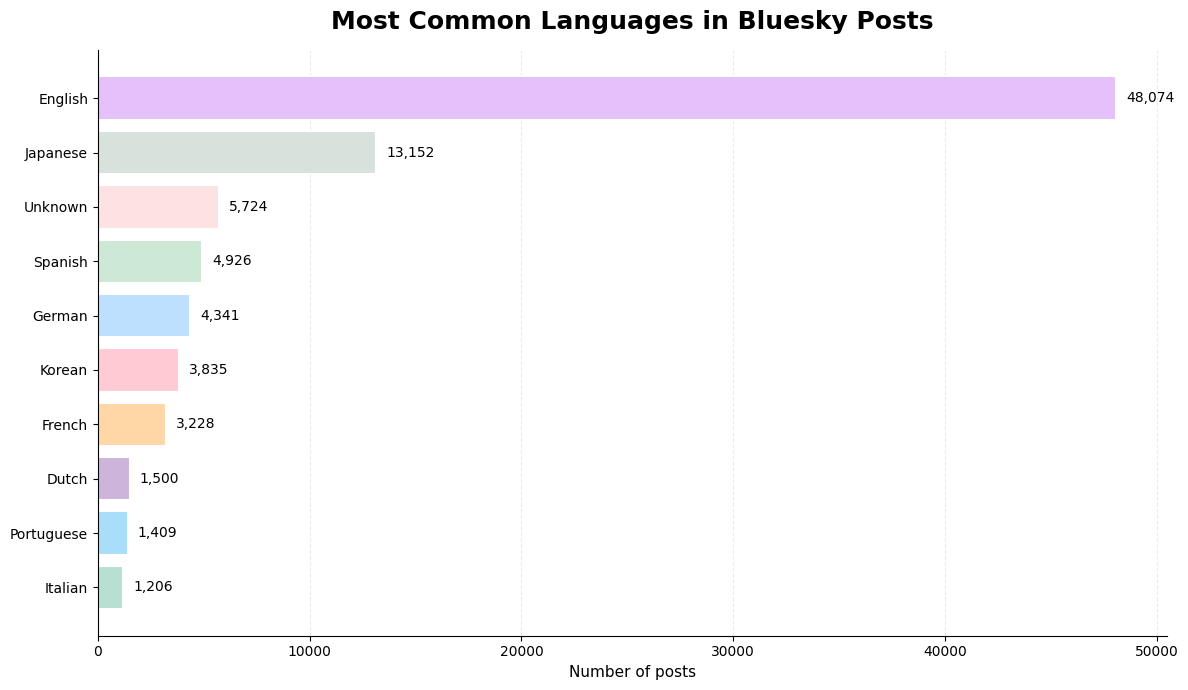

In [ ]:
# ============================================================
# QUESTION 2: Visualization - ภาษาที่พบในข้อมูล
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. รีเซ็ตฟอนต์
# ============================================================

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 2. เลือก 10 ภาษาที่พบมากที่สุด
# ============================================================

top_languages = (
    language_summary
    .head(10)
    .sort_values("Posts", ascending=True)
)

# ============================================================
# 3. สี Pastel
# ============================================================

pastel_colors = [
    "#B8E0D2",
    "#A9DEF9",
    "#CDB4DB",
    "#FFD6A5",
    "#FFCAD4",
    "#BDE0FE",
    "#CDE8D5",
    "#FDE2E4",
    "#D8E2DC",
    "#E4C1F9"
]

# ============================================================
# 4. สร้างกราฟ
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_languages["Language"],
    top_languages["Posts"],
    color=pastel_colors[:len(top_languages)],
    edgecolor="white",
    linewidth=1.5
)

# ============================================================
# 5. แสดงจำนวนโพสต์
# ============================================================

max_value = top_languages["Posts"].max()

for bar in bars:

    value = bar.get_width()

    ax.text(
        value + max_value * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center",
        fontsize=10
    )

# ============================================================
# 6. ชื่อกราฟ
# ============================================================

ax.set_title(
    "Most Common Languages in Bluesky Posts",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of posts",
    fontsize=11
)

ax.set_ylabel("")

# ============================================================
# 7. Grid
# ============================================================

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

# ============================================================
# 8. ซ่อนเส้นกรอบ
# ============================================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ============================================================
# 9. แสดงผล
# ============================================================

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# QUESTION 3: คนพูดถึงอะไร
# วิเคราะห์ Hashtag และ Phrase ที่โดดเด่น
# ============================================================

import re
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer


print("\n\n==========================================")
print("QUESTION 3: คนพูดถึงอะไร")
print("==========================================")


# ============================================================
# 3.1 HASHTAG
# ============================================================

print("\n[3.1] Hashtag ที่พบมากที่สุด")
print("-" * 60)


hashtags = []

for text in df["text"].dropna():

    tags = re.findall(
        r"#\w+",
        str(text)
    )

    hashtags.extend(tags)


# นับจำนวน Hashtag
hashtag_count = Counter(hashtags)


# สร้างตาราง Hashtag
hashtag_df = pd.DataFrame(
    hashtag_count.most_common(20),
    columns=["Hashtag", "Count"]
)


print("\n20 Hashtag ที่พบมากที่สุด:")
display(hashtag_df)


# ============================================================
# 3.2 เตรียมข้อความสำหรับหา Phrase
# ============================================================

print("\n[3.2] เตรียมข้อความสำหรับวิเคราะห์ Phrase")
print("-" * 60)


texts = (
    df["text"]
    .dropna()
    .astype(str)
)


clean_texts = []


for text in texts:

    # --------------------------------------------------------
    # แปลงเป็นตัวพิมพ์เล็ก
    # --------------------------------------------------------

    text = text.lower()


    # --------------------------------------------------------
    # ลบ URL
    # --------------------------------------------------------

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )


    # --------------------------------------------------------
    # ลบเครื่องหมาย # แต่เก็บคำไว้
    # เช่น #digitalart → digitalart
    # --------------------------------------------------------

    text = re.sub(
        r"#([a-zA-Z]+)",
        r"\1",
        text
    )


    # --------------------------------------------------------
    # เก็บเฉพาะตัวอักษรภาษาอังกฤษและช่องว่าง
    # --------------------------------------------------------

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )


    # --------------------------------------------------------
    # ลดช่องว่างซ้ำ
    # --------------------------------------------------------

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()


    clean_texts.append(text)


# ============================================================
# 3.3 หา Phrase 2–4 คำด้วย TF-IDF
# ============================================================

print("\n[3.3] วิเคราะห์ Phrase 2–4 คำ")
print("-" * 60)


vectorizer = TfidfVectorizer(

    # ตัดคำทั่วไป เช่น
    # the, is, of, and, to
    stop_words="english",

    # หา Phrase ตั้งแต่ 2–4 คำ
    ngram_range=(2, 4),

    # ต้องพบอย่างน้อย 10 โพสต์
    # เพื่อป้องกันวลีที่พบเพียงไม่กี่ครั้ง
    min_df=10,

    # จำกัดจำนวน Phrase
    max_features=3000
)


X = vectorizer.fit_transform(clean_texts)


# ============================================================
# 3.4 คำนวณคะแนน TF-IDF
# ============================================================

phrase_scores = X.mean(axis=0).A1

phrases = vectorizer.get_feature_names_out()


phrase_df = pd.DataFrame({
    "Phrase": phrases,
    "TFIDF_Score": phrase_scores
})


# ============================================================
# 3.5 เรียงจาก Phrase ที่โดดเด่นมาก → น้อย
# ============================================================

phrase_df = (
    phrase_df
    .sort_values(
        "TFIDF_Score",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 3.6 แสดง Phrase ที่โดดเด่น
# ============================================================

print("\n20 Phrase ที่โดดเด่นที่สุด:")
print("-" * 60)

display(
    phrase_df.head(20)
)


# ============================================================
# 3.7 แสดงตัวอย่างข้อความจริงของแต่ละ Phrase
# ============================================================

print("\n[3.7] ตัวอย่างข้อความจริงประกอบ Phrase")
print("-" * 60)


top_phrases = (
    phrase_df
    .head(10)["Phrase"]
    .tolist()
)


for rank, phrase in enumerate(top_phrases, 1):

    matched_post = None

    for original_text in texts:

        if phrase in original_text.lower():

            matched_post = original_text
            break


    print(f"\n{rank}. Phrase: {phrase}")

    if matched_post:

        print("   ตัวอย่างข้อความ:")
        print("   ", matched_post)

    else:

        print("   ไม่พบข้อความตัวอย่าง")


# ============================================================
# 3.8 สรุป Phrase ที่นำไปใช้ในรายงาน
# ============================================================

print("\n==========================================")
print("สรุป Phrase ที่โดดเด่น")
print("==========================================")


display(
    phrase_df[
        ["Phrase", "TFIDF_Score"]
    ].head(10)
)



QUESTION 3: คนพูดถึงอะไร

[3.1] Hashtag ที่พบมากที่สุด
------------------------------------------------------------

20 Hashtag ที่พบมากที่สุด:


,Hashtag,Count
0,#art,245
1,#nsfw,162
2,#innovation,111
3,#photography,104
4,#BookSky,92
5,#BookChallenge,74
6,#SSI,68
7,#Books,64
8,#cybersécurité,64
9,#porn,62



[3.2] เตรียมข้อความสำหรับวิเคราะห์ Phrase
------------------------------------------------------------

[3.3] วิเคราะห์ Phrase 2–4 คำ
------------------------------------------------------------

20 Phrase ที่โดดเด่นที่สุด:
------------------------------------------------------------


,Phrase,TFIDF_Score
0,bsky social,0.013815
1,good morning,0.003900
2,bsky app,0.002165
3,don know,0.001682
4,feel like,0.001582
5,en el,0.001552
6,years ago,0.001508
7,app profile,0.001498
8,bsky app profile,0.001498
9,looks like,0.001454



[3.7] ตัวอย่างข้อความจริงประกอบ Phrase
------------------------------------------------------------

1. Phrase: bsky social
   ตัวอย่างข้อความ:
    Love it! Also hhiiiii on bsky social! :D

2. Phrase: good morning
   ตัวอย่างข้อความ:
    Good morning Captain Cyber!
Wednesday will soon be beaten 😅. There’s no thanksgiving for me so I’ll be fighting Thursday alongside you too tomorrow! Hope you have an awesome day my friend ☺️

3. Phrase: bsky app
   ไม่พบข้อความตัวอย่าง

4. Phrase: don know
   ไม่พบข้อความตัวอย่าง

5. Phrase: feel like
   ตัวอย่างข้อความ:
    Current GW13 thoughts:

Having to play one of ESR and Rogers due to Semenyo suspension. Would rather ESR with Vicario’s injury, but don’t want to transfer out Semenyo or Rogers yet. Fulham’s fixtures take a weird turn now, so feel like ESR transfer + play Rogers is better long term 🤔

6. Phrase: en el
   ตัวอย่างข้อความ:
    En el Slagalica de hoy han mencionado a las Feminnem y su paso por Eurovisión У Слагалици су данас поменули

,Phrase,TFIDF_Score
0,bsky social,0.013815
1,good morning,0.003900
2,bsky app,0.002165
3,don know,0.001682
4,feel like,0.001582
5,en el,0.001552
6,years ago,0.001508
7,app profile,0.001498
8,bsky app profile,0.001498
9,looks like,0.001454


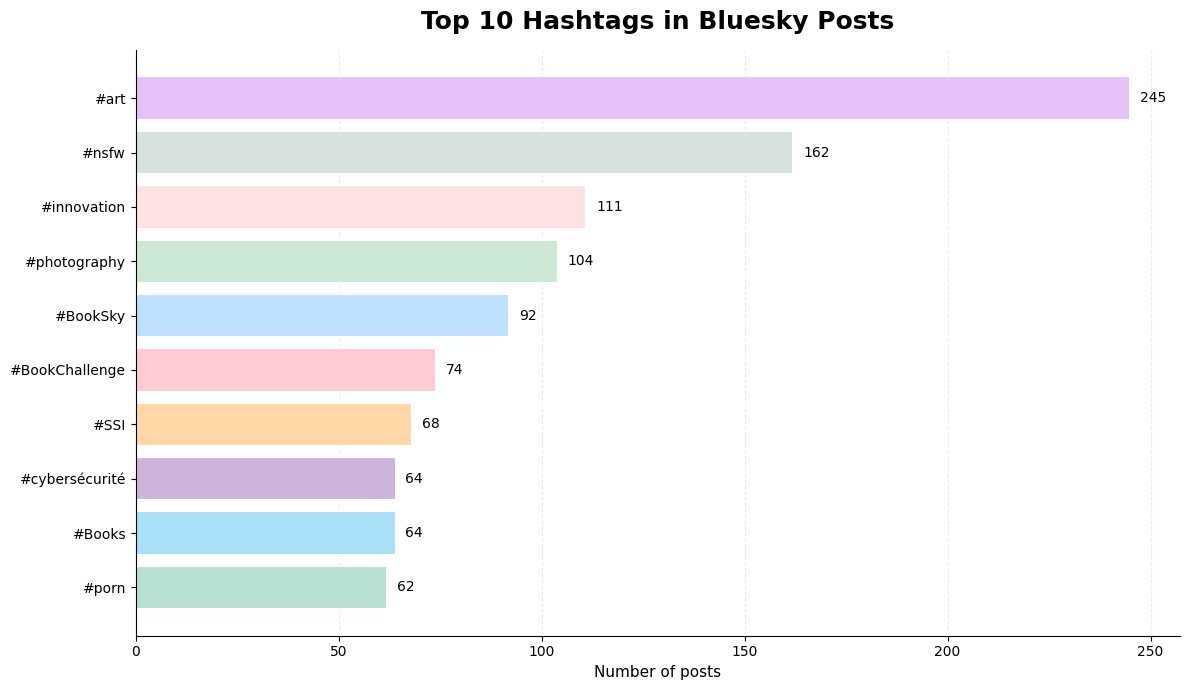

In [ ]:
# ============================================================
# 3.9 Visualization: Hashtag ที่พบมากที่สุด
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# เลือก 10 Hashtag แรก
# ------------------------------------------------------------

top_hashtags = (
    hashtag_df
    .head(10)
    .sort_values("Count", ascending=True)
)

# ------------------------------------------------------------
# สี Pastel
# ------------------------------------------------------------

pastel_colors = [
    "#B8E0D2",
    "#A9DEF9",
    "#CDB4DB",
    "#FFD6A5",
    "#FFCAD4",
    "#BDE0FE",
    "#CDE8D5",
    "#FDE2E4",
    "#D8E2DC",
    "#E4C1F9"
]

# ------------------------------------------------------------
# สร้างกราฟ
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_hashtags["Hashtag"],
    top_hashtags["Count"],
    color=pastel_colors[:len(top_hashtags)],
    edgecolor="white",
    linewidth=1.5
)

# ------------------------------------------------------------
# แสดงจำนวนโพสต์
# ------------------------------------------------------------

max_value = top_hashtags["Count"].max()

for bar in bars:

    value = bar.get_width()

    ax.text(
        value + max_value * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center",
        fontsize=10
    )

# ------------------------------------------------------------
# ตกแต่งกราฟ
# ------------------------------------------------------------

ax.set_title(
    "Top 10 Hashtags in Bluesky Posts",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of posts",
    fontsize=11
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

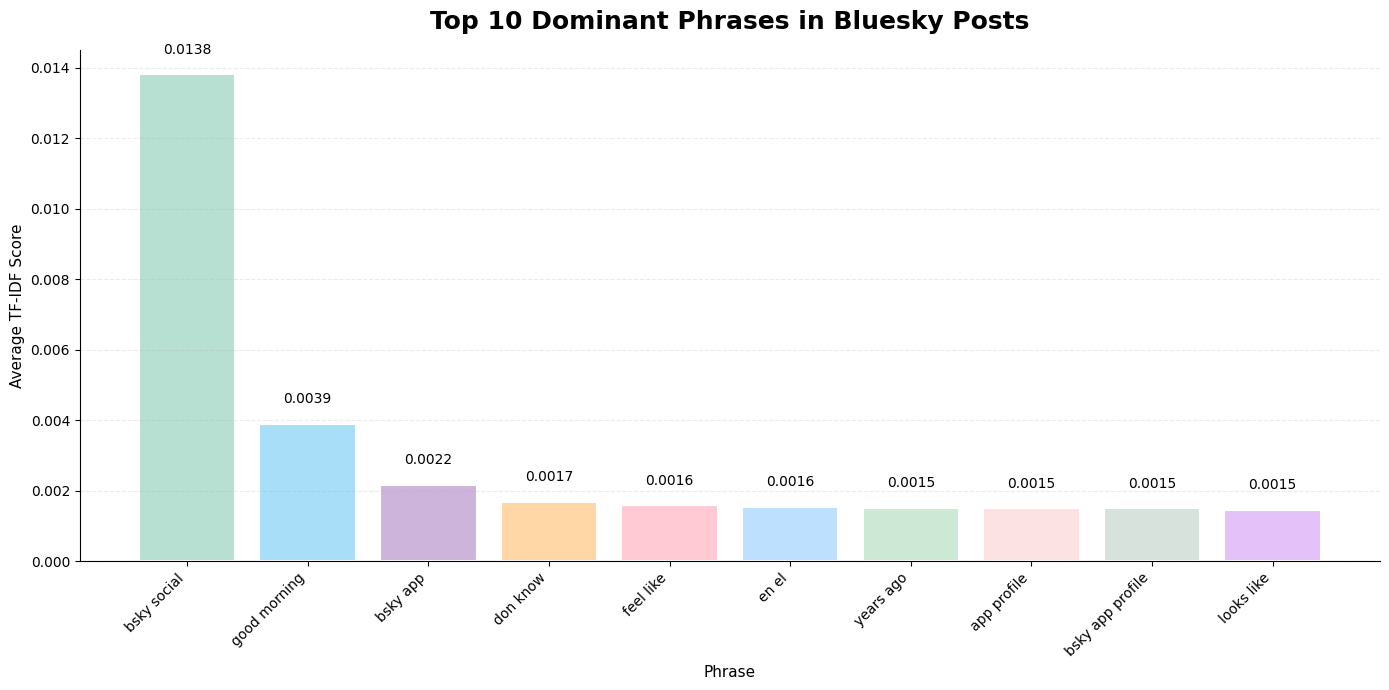

In [ ]:
# ============================================================
# 3.9 Visualization: Top 10 Dominant Phrases
# ============================================================

import matplotlib.pyplot as plt

# ใช้ข้อมูลจาก phrase_df เดิมโดยตรง
top_phrases_chart = phrase_df.head(10).copy()

# แก้ปัญหา font warning
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# สีพาสเทล
pastel_colors = [
    "#B8E0D2", "#A9DEF9", "#CDB4DB", "#FFD6A5", "#FFCAD4",
    "#BDE0FE", "#CDE8D5", "#FDE2E4", "#D8E2DC", "#E4C1F9"
]

plt.figure(figsize=(14, 7))

bars = plt.bar(
    top_phrases_chart["Phrase"],
    top_phrases_chart["TFIDF_Score"],
    color=pastel_colors,
    edgecolor="white",
    linewidth=1.5
)

# แสดงค่าบนแท่ง
for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.0005,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Top 10 Dominant Phrases in Bluesky Posts",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel("Phrase", fontsize=11)
plt.ylabel("Average TF-IDF Score", fontsize=11)

plt.xticks(rotation=45, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()



QUESTION 4: ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้


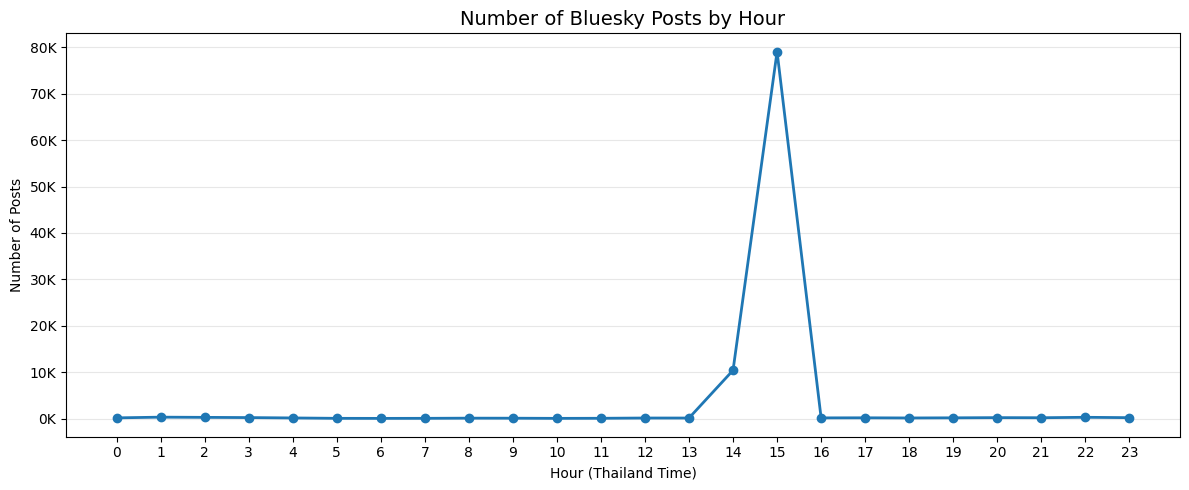


========== ข้อมูลนี้บอกอะไรได้ ==========
1. สามารถบอกช่วงเวลาที่มีการโพสต์มากและน้อยได้
2. สามารถเปรียบเทียบรูปแบบการใช้งานในแต่ละช่วงเวลาได้
3. สามารถระบุช่วงเวลาที่มีจำนวนโพสต์สูงสุดได้

========== ข้อมูลนี้บอกอะไรไม่ได้ / ข้อจำกัด ==========
1. ข้อมูลไม่สามารถบอกได้ว่าผู้โพสต์เป็นตัวแทนของผู้ใช้ Bluesky ทั้งหมดหรือไม่
2. ไม่สามารถสรุปได้ว่าผู้ใช้โพสต์ในช่วงเวลาดังกล่าวเพราะเหตุผลใด
3. ข้อมูลไม่สามารถบอกได้ว่าโพสต์มีความคิดเห็น ความรู้สึก หรือเจตนาอย่างไรโดยตรง
4. ข้อมูลชุดนี้เป็นเพียงส่วนหนึ่งของโพสต์ จึงไม่ควรนำไปสรุปพฤติกรรมของผู้ใช้ทั้งหมด


In [ ]:
# ============================================================
# QUESTION 4
# ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้
# ============================================================

import matplotlib.pyplot as plt


print("\n\n==========================================")
print("QUESTION 4: ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้")
print("==========================================")


# ============================================================
# 4.1 Visualization
# จำนวนโพสต์ตามช่วงเวลา
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# นับจำนวนโพสต์ในแต่ละชั่วโมง
# ------------------------------------------------------------

hour_count = (
    df["hour_th"]
    .value_counts()
    .reindex(range(24), fill_value=0)
)


# ------------------------------------------------------------
# สร้างกราฟ
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    hour_count.index,
    hour_count.values,
    marker="o",
    linewidth=2
)


# ------------------------------------------------------------
# ตั้งชื่อกราฟ
# ------------------------------------------------------------

plt.title(
    "Number of Bluesky Posts by Hour",
    fontsize=14
)

plt.xlabel(
    "Hour (Thailand Time)"
)

plt.ylabel(
    "Number of Posts"
)


# ------------------------------------------------------------
# แสดงแกน X ทุกชั่วโมง
# ------------------------------------------------------------

plt.xticks(range(24))


# ------------------------------------------------------------
# ปรับแกน Y ให้แสดงเป็นจำนวนพัน
# ------------------------------------------------------------

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x/1000:.0f}K"
    )
)


# ------------------------------------------------------------
# แสดงเส้น Grid
# ------------------------------------------------------------

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 4.2 ข้อมูลนี้บอกอะไรได้
# ============================================================

print("\n========== ข้อมูลนี้บอกอะไรได้ ==========")

print(
    "1. สามารถบอกช่วงเวลาที่มีการโพสต์มากและน้อยได้"
)

print(
    "2. สามารถเปรียบเทียบรูปแบบการใช้งานในแต่ละช่วงเวลาได้"
)

print(
    "3. สามารถระบุช่วงเวลาที่มีจำนวนโพสต์สูงสุดได้"
)


# ============================================================
# 4.3 ข้อมูลนี้บอกอะไรไม่ได้ / ข้อจำกัด
# ============================================================

print("\n========== ข้อมูลนี้บอกอะไรไม่ได้ / ข้อจำกัด ==========")

print(
    "1. ข้อมูลไม่สามารถบอกได้ว่าผู้โพสต์เป็นตัวแทนของผู้ใช้ Bluesky ทั้งหมดหรือไม่"
)

print(
    "2. ไม่สามารถสรุปได้ว่าผู้ใช้โพสต์ในช่วงเวลาดังกล่าวเพราะเหตุผลใด"
)

print(
    "3. ข้อมูลไม่สามารถบอกได้ว่าโพสต์มีความคิดเห็น ความรู้สึก หรือเจตนาอย่างไรโดยตรง"
)

print(
    "4. ข้อมูลชุดนี้เป็นเพียงส่วนหนึ่งของโพสต์ จึงไม่ควรนำไปสรุปพฤติกรรมของผู้ใช้ทั้งหมด"
)

ข้อมูลนี้บอกอะไรได้
บอกได้ว่า ผู้ใช้โพสต์ในช่วงเวลาใดมากหรือน้อย
บอกได้ว่า ช่วงเวลาไหนมีจำนวนโพสต์หนาแน่นที่สุด
บอกได้ว่า รูปแบบการโพสต์แตกต่างกันอย่างไรในแต่ละปีและช่วงเวลา
ใช้ช่วยวางแผน ช่วงเวลาที่เหมาะสมสำหรับการโพสต์หรือทำ Content
ข้อมูลนี้บอกอะไรไม่ได้
บอกไม่ได้ว่า ทำไมผู้ใช้จึงโพสต์ในช่วงเวลานั้น
บอกไม่ได้ว่า ผู้ใช้มีความรู้สึกหรือความคิดเห็นอย่างไร
บอกไม่ได้ว่า โพสต์จำนวนมากหมายถึงผู้ใช้สนใจเรื่องใด
บอกไม่ได้ว่า ผู้ใช้ทั้งหมดบน Bluesky มีพฤติกรรมเหมือนข้อมูลชุดนี้ เพราะเป็นเพียงข้อมูลตัวอย่าง 100,000 โพสต์
จึงควรนำข้อมูล เนื้อหา ภาษา และ Hashtag มาวิเคราะห์ร่วมกันเพื่อให้ได้ Insight ที่ลึกขึ้น

**<สรุปสั้น ๆ ถึงลูกค้า 5 บรรทัด>**

* ข้อมูล 100,000 โพสต์ช่วยให้เห็นช่วงเวลาที่ผู้ใช้มีการโพสต์หนาแน่นในแต่ละปี
พบว่าจำนวนโพสต์แตกต่างกันตามช่วงเวลา โดยช่วง 15:00–15:59 น. มีโพสต์สูงที่สุดในชุดข้อมูล
ข้อมูลนี้สามารถใช้ประกอบการเลือกช่วงเวลาในการเผยแพร่เนื้อหาหรือสื่อสารกับผู้ใช้
อย่างไรก็ตาม จำนวนโพสต์ไม่สามารถบอกได้ว่าผู้ใช้โพสต์เพราะเหตุใด หรือมีความคิดเห็นและความรู้สึกอย่างไร
ดังนั้น ควรใช้ข้อมูลด้านเวลาร่วมกับเนื้อหาและข้อมูลอื่น ๆ เพื่อให้ได้ Insight ที่นำไปใช้ทางธุรกิจได้แม่นยำขึ้น

